In [5]:
import glob
import pickle

from tqdm import tqdm


In [18]:

## val
paths = {
    # 'p0.75-e0.1': "../runs/minif2f/combined_model-p0.75-e0.1/2024_08_15/17_29_37/traces/0/",
    # 'p_0.5_e_0.1': "../runs/minif2f/combined_model-p0.5-e0.1/2024_08_15/15_11_20/traces/0/",
    # "p0.5_e0.5": "../runs/minif2f/combined_model-p0.5-e0.5/2024_08_20/02_15_00/traces/0/",
    # 
    # 'p_0.99_e_0.1': "../runs/minif2f/combined_model-p0.99-e0.1/2024_08_17/07_26_05/traces/0/",
    # 'p0.95-e0.1': "../runs/minif2f/combined_model-p0.95-e0.1/2024_08_17/10_45_17/traces/0/",
    # 'p_0.9_e_0.5': "../runs/minif2f/combined_model-p0.9-e0.5/2024_08_19/01_35_19/traces/0/",
    # 'p0.9-e0.1': "../runs/minif2f/combined_model-p0.9-e0.1/2024_08_16/16_45_36/traces/0/",
    # 'p0.75-e0.5': "../runs/minif2f/combined_model-p0.75-e0.5/2024_08_18/02_44_45/traces/0/",
    # 'p0.95-e0.5': "../runs/minif2f/combined_model-p0.95-e0.5/2024_08_19/19_21_11/traces/0/",
    # 
    # 'p0.25-e0.1':"../runs/minif2f/combined_model-p0.25-e0.1/2024_08_17/21_43_40/traces/0/",

    # 'p0.5-e0.1-t4': "../runs/minif2f/combined_model-p0.5-e0.1-t4/2024_08_25/10_12_12/traces/0/",
    # 'p0.75-e0.1-t1': "../runs/minif2f/combined_model-p0.75-e0.1-t1/2024_08_24/12_59_42/traces/0/",
    # 'p0.75-e0.1-t4': "../runs/minif2f/combined_model-p0.75-e0.1-t4/2024_08_23/15_26_24/traces/0/",
    # 'no_score_net_p0.5-t1': "../runs/minif2f/no_score_net-p0.5/2024_08_24/16_59_43/traces/0/",
    # 'no_score_net_p0.75-t1': "../runs/minif2f/no_score_net-p0.75/2024_08_26/07_59_45/traces/0/"

    # 'k_16': "../runs/minif2f/fixed_no_score-k16/2024_08_28/16_02_42/traces/0/",
    # 'k_8_e0.5': "../runs/minif2f/fixed_combined-k8-e0.5/2024_08_30/10_11_23/traces/0/",

    'bestfs': "../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/",
    # 'bestfs_8_top': "../runs/minif2f/bestfs_topk-k8-rFalse/2024_08_20/16_19_27/traces/0/",
    'bestfs_8_random': "../runs/minif2f/bestfs_topk-k8-rTrue/2024_08_21/08_45_42/traces/0/",
    'bestfs_16_top': "../runs/minif2f/bestfs_topk-k16-rFalse/2024_08_21/22_44_33/traces/0/",
    'bestfs_16_random': "../runs/minif2f/bestfs_topk-k16-rTrue/2024_08_22/12_32_56/traces/0/",
    'bestfs_32_top': "../runs/minif2f/bestfs_topk-k32-rFalse/2024_08_22/10_11_13/traces/0/",
    'bestfs_32_random': "../runs/minif2f/bestfs_topk-k32-rTrue/2024_08_22/22_06_14/traces/0/",
    # 'bestfs_48_top': "../runs/minif2f/bestfs_topk-k48-rFalse/2024_08_23/10_01_44/traces/0/",


    'k16': "../runs/minif2f/fixed_no_score-k16/2024_08_28/16_02_42/traces/0/",
    # 'k8': "../runs/minif2f/fixed_no_score-k8/2024_08_26/15_54_16/traces/0/",
    'k32':"../runs/minif2f/fixed_no_score-k32/2024_08_29/17_51_47/traces/0/",
    
    
}

# paths = {
#     'bestfs_8_top': "../runs/minif2f/bestfs_topk-k8-rFalse/2024_08_20/16_19_27/traces/0/",
#     'bestfs_8_random': "../runs/minif2f/bestfs_topk-k8-rTrue/2024_08_21/08_45_42/traces/0/",
#     'bestfs_16_top': "../runs/minif2f/bestfs_topk-k16-rFalse/2024_08_21/22_44_33/traces/0/",
#     'bestfs_16_random': "../runs/minif2f/bestfs_topk-k16-rTrue/2024_08_22/12_32_56/traces/0/",
#     'bestfs_32_top': "../runs/minif2f/bestfs_topk-k32-rFalse/2024_08_22/10_11_13/traces/0/",
#     'bestfs_32_random': "../runs/minif2f/bestfs_topk-k32-rTrue/2024_08_22/22_06_14/traces/0/",
# 
#     'k8_e0.1': "../runs/minif2f/fixed_combined-k8-e0.1/2024_08_26/15_49_54/traces/0/",
#     'k32_e0.1': "../runs/minif2f/fixed_combined-k32-e0.1/2024_08_29/17_42_42/traces/0/",
#     'k16_e0.1': "../runs/minif2f/fixed_combined-k16-e0.1/2024_08_28/16_04_20/traces/0/",
# 
#     'k8_e0.5': "../runs/minif2f/fixed_combined-k8-e0.5/2024_08_30/10_11_23/traces/0/",
#     'k32_e0.5': "../runs/minif2f/fixed_combined-k32-e0.5/2024_09_03/03_06_56/traces/0/",
#     'k16_e0.5': "../runs/minif2f/fixed_combined-k16-e0.5/2024_09_01/10_38_04/traces/0/",
# 
#     'k8_t1': "../runs/minif2f/time_ablation-k8/2024_09_23/14_44_44/traces/0/",
#     'k16_t1': "../runs/minif2f/time_ablation-k16/2024_09_25/14_21_15/traces/0/",
#     'k32_t1': "../runs/minif2f/time_ablation-k32/2024_09_26/18_46_33/traces/0/",
# 
#     'k32_theta4': "../runs/minif2f/temp_ablation-k32/2024_09_23/14_45_18/traces/0/",
#     'k16_theta4': "../runs/minif2f/temp_ablation-k16/2024_09_24/07_08_43/traces/0/",
#     'k8_theta4': "../runs/minif2f/temp_ablation-k8/2024_09_25/10_06_32/traces/0/",
# 
#     'k16': "../runs/minif2f/fixed_no_score-k16/2024_08_28/16_02_42/traces/0/",
#     'k8': "../runs/minif2f/fixed_no_score-k8/2024_08_26/15_54_16/traces/0/",
#     'k32': "../runs/minif2f/fixed_no_score-k32/2024_08_29/17_51_47/traces/0/",
# 
# }


## test
# paths = {
# ## BestFS with not subgoal split
#     ## pass@k = 68
#     'bestfs_8_1': '../runs/minif2f_test/bestfs_topk-k8-rTrue/2024_08_31/09_28_42/traces/0/',
#     'bestfs_8_2': '../runs/minif2f_test/2_bestfs_topk-k8-rTrue/2024_09_03/15_39_10/traces/0/',
#     'bestfs_8_3': '../runs/minif2f_test/2_bestfs_topk-k8-rTrue/2024_09_05/11_45_38/traces/0/',
#     'bestfs_8_4': '../runs/minif2f_test/4_bestfs_topk-k8-rTrue/2024_09_07/09_36_04/traces/0/',
#     # 
# 
#     ## pass@k = 72
#     'bestfs_16_1': "../runs/minif2f_test/bestfs_topk-k16-rTrue/2024_09_01/15_01_20/traces/0/",
#     'bestfs_16_2': "../runs/minif2f_test/2_bestfs_topk-k16-rTrue/2024_09_04/06_22_00/traces/0/",
#     'bestfs_16_3': "../runs/minif2f_test/2_bestfs_topk-k16-rTrue/2024_09_06/02_45_19/traces/0/",
#     'bestfs_16_4': "../runs/minif2f_test/4_bestfs_topk-k16-rTrue/2024_09_08/01_05_18/traces/0/",
#     # 
# 
# 
#     ## pass@k = 72
#     'bestfs_32_1': "../runs/minif2f_test/bestfs_topk-k32-rTrue/2024_09_02/19_52_42/traces/0/",
#     'bestfs_32_2': "../runs/minif2f_test/2_bestfs_topk-k32-rTrue/2024_09_04/22_02_48/traces/0/",
#     'bestfs_32_3': "../runs/minif2f_test/2_bestfs_topk-k32-rTrue/2024_09_06/17_55_05/traces/0/",
#     'bestfs_32_4': "../runs/minif2f_test/4_bestfs_topk-k32-rTrue/2024_09_08/16_33_01/traces/0/",
#     # 
# 
#     ## pass@k = 70
#     'dpp_8_1': "../runs/minif2f_test/val_model_fixed-k8/2024_09_11/21_19_23/traces/0/",
#     'dpp_8_2': "../runs/minif2f_test/val_fixed-k8/2024_09_14/12_23_35/traces/0/",
#     'dpp_8_3': "../runs/minif2f_test/3_val_combined-k8/2024_09_18/11_45_42/traces/0/",
#     'dpp_8_4': "../runs/minif2f_test/4_val_fixed-k8/2024_09_19/21_24_42/traces/0/",
#     #            
# 
#     ## pass@k = 76
#     'dpp_16_1': "../runs/minif2f_test/val_model_fixed-k16/2024_09_10/08_38_24/traces/0/",
#     'dpp_16_2': "../runs/minif2f_test/val_fixed-k16/2024_09_13/10_24_37/traces/0/",
#     'dpp_16_3': "../runs/minif2f_test/3_val_combined-k16/2024_09_21/03_59_33/traces/0/",
#     'dpp_16_4': "../runs/minif2f_test/4_val_fixed-k16/2024_09_18/15_33_17/traces/0/",
# 
#     ## pass@k = 73
#     'dpp_32_1': "../runs/minif2f_test/val_model_fixed-k32/2024_09_09/11_43_04/traces/0/",
#     'dpp_32_2': "../runs/minif2f_test/val_fixed-k32/2024_09_12/17_23_34/traces/0/",
#     'dpp_32_3': "../runs/minif2f_test/3_val_model-k32/2024_09_14/16_30_34/traces/0/",
#     'dpp_32_4': "../runs/minif2f_test/3_val_combined-k32/2024_09_22/16_43_11/traces/0/"
# }
# 

# paths = {
# 
#     ## pass@k = 70
#     'dpp_8_1': "../runs/minif2f_test/val_model_fixed-k8/2024_09_11/21_19_23/traces/0/",
#     'dpp_8_2': "../runs/minif2f_test/val_fixed-k8/2024_09_14/12_23_35/traces/0/",
#     'dpp_8_3': "../runs/minif2f_test/3_val_combined-k8/2024_09_18/11_45_42/traces/0/",
#     'dpp_8_4': "../runs/minif2f_test/4_val_fixed-k8/2024_09_19/21_24_42/traces/0/",
# 
#     ## pass@k = 76
#     'dpp_16_1': "../runs/minif2f_test/val_model_fixed-k16/2024_09_10/08_38_24/traces/0/",
#     'dpp_16_2': "../runs/minif2f_test/val_fixed-k16/2024_09_13/10_24_37/traces/0/",
#     'dpp_16_3': "../runs/minif2f_test/3_val_combined-k16/2024_09_21/03_59_33/traces/0/",
#     'dpp_16_4': "../runs/minif2f_test/4_val_fixed-k16/2024_09_18/15_33_17/traces/0/",
# 
#     ## pass@k = 73
#     'dpp_32_1': "../runs/minif2f_test/val_model_fixed-k32/2024_09_09/11_43_04/traces/0/",
#     'dpp_32_2': "../runs/minif2f_test/val_fixed-k32/2024_09_12/17_23_34/traces/0/",
#     'dpp_32_3': "../runs/minif2f_test/3_val_model-k32/2024_09_14/16_30_34/traces/0/",
#     'dpp_32_4': "../runs/minif2f_test/3_val_combined-k32/2024_09_22/16_43_11/traces/0/",
# 
#     'bestfs_8_1': '../runs/minif2f_test/baseline-k8-rTrue/2024_10_01/12_21_06/traces/0/',
#     'bestfs_8_2': '../runs/minif2f_test/baseline-k8-rTrue/2024_09_30/14_49_53/traces/0/',
#     'bestfs_8_3': '../runs/minif2f_test/baseline-k8-rTrue/2024_09_28/10_26_36/traces/0/',
#     'bestfs_8_4': '../runs/minif2f_test/baseline-k8-rTrue/2024_09_27/18_23_05/traces/0/',
# 
#     'bestfs_16_1': '../runs/minif2f_test/baseline-k16-rTrue/2024_10_02/03_15_54/traces/0/',
#     'bestfs_16_2': '../runs/minif2f_test/baseline-k16-rTrue/2024_10_01/04_55_50/traces/0/',
#     'bestfs_16_3': '../runs/minif2f_test/baseline-k16-rTrue/2024_09_29/17_43_50/traces/0/',
#     'bestfs_16_4': '../runs/minif2f_test/baseline-k16-rTrue/2024_09_28/09_55_26/traces/0/',
# 
#     'bestfs_32_1': '../runs/minif2f_test/baseline-k32-rTrue/2024_10_01/19_50_42/traces/0/',
#     'bestfs_32_2': '../runs/minif2f_test/baseline-k32-rTrue/2024_09_30/22_25_23/traces/0/',
#     'bestfs_32_3': '../runs/minif2f_test/baseline-k32-rTrue/2024_09_29/00_53_25/traces/0/',
# 
# 
#     'bestfs_8_top': "../runs/minif2f_test/baseline-k8-rFalse/2024_09_27/15_41_19/traces/0/",
#     'bestfs_16_top': "../runs/minif2f_test/baseline-k16-rFalse/2024_09_29/01_47_24/traces/0/",
#     'bestfs_32_top': "../runs/minif2f_test/baseline-k32-rFalse/2024_09_30/09_17_02/traces/0/",
# }



In [11]:

paths = {
    # 'leandojo_3dprover_32': "../runs/leandojo_novel_premises/3d_prover-k32/2024_10_29/17_11_25/traces/0/",

    # 'topk_32': "../runs/leandojo_novel_premises/baseline-k32-rFalse/2024_10_29/15_50_40/traces/0/",

    # 'no_filter': "../runs/end_to_end/no_split_a6000-2/2024_05_30/16_08_18/traces/0/"
}


In [76]:
def get_times(path):
    files = glob.glob(path + '*', recursive=True)
    # traces_ = []

    times = []
    for file in tqdm(files):
        try:
            trace = pickle.load(open(file, "rb"))
            if trace.proof:
                times.append(trace.env_time)
        except:
            continue

    return times


In [4]:

trace_times = {}

for key, path in paths.items():
    times = get_times(path)
    trace_times[key] = times

    print(key, sum(trace_times[key]) / len(trace_times[key]))



100%|██████████| 244/244 [00:15<00:00, 15.91it/s]


bestfs 142.00781582695473


100%|██████████| 244/244 [00:25<00:00,  9.69it/s]


bestfs_8_top 49.66203819735433


100%|██████████| 244/244 [00:15<00:00, 15.56it/s]


...

k16 104.80100049591348


100%|██████████| 244/244 [00:36<00:00,  6.68it/s]


k8 62.05595418806264


100%|██████████| 244/244 [00:22<00:00, 10.94it/s]

k32 119.57216800871039


In [7]:
def get_proven(path):
    files = glob.glob(path + '*', recursive=True)
    # traces_ = []

    proven = []
    proofs = []
    time = []
    for file in tqdm(files):
        try:
            # traces_.append(pickle.load(open(file, "rb")))
            trace = pickle.load(open(file, "rb"))
            if trace.proof:
                proven.append(trace.theorem.full_name)
                proofs.append((trace.theorem.full_name, trace.proof))
                time.append(trace.total_time)
        except:
            # print ('Failed to load:', file)
            continue

    return proven, proofs, time


In [19]:

# traces_proved = {}
# trace_proofs = {}


for key, path in paths.items():
    proven, proofs, time = get_proven(path)
    traces_proved[key] = proven, time
    trace_proofs[key] = proofs

    print(key, len(traces_proved[key]))



100%|██████████| 244/244 [00:13<00:00, 18.05it/s]


bestfs 2


100%|██████████| 244/244 [00:14<00:00, 16.41it/s]


bestfs_8_random 2


100%|██████████| 244/244 [00:18<00:00, 13.55it/s]


...

bestfs_32_random 2


100%|██████████| 244/244 [00:28<00:00,  8.52it/s]


k16 2


100%|██████████| 244/244 [00:20<00:00, 11.64it/s]

k32 2


In [81]:
# get the intersection of proved theorems, and number unique to each set

traces_proved = {key: set(value) for key, value in traces_proved.items()}

In [9]:

for key, value in traces_proved.items():
    print(key, len(value))


bestfs_8_top 2
k8 2


In [15]:
len([a for a in traces_proved['bestfs_8_top'][1] if a <= 600])

52

In [17]:
len([a for a in traces_proved['k8'][1] if a <= 600])

58

In [50]:
for key, value in traces_proved.items():
    print(key, len([a for a in value[1] if a <= 830]) / 244)

bestfs_8_top 0.21721311475409835
k8 0.23770491803278687
bestfs 0.2786885245901639
bestfs_8_random 0.1885245901639344
bestfs_16_top 0.26639344262295084
bestfs_16_random 0.24180327868852458
bestfs_32_top 0.2786885245901639
bestfs_32_random 0.27459016393442626
k16 0.2786885245901639
k32 0.2786885245901639


In [31]:
67 / 244


0.27459016393442626

In [32]:
67 / 66

1.0151515151515151

In [ ]:
import numpy as np

print(np.mean([len(value) / 245 for key, value in traces_proved.items() if '32' in key]))
print(np.std([len(value) / 245 for key, value in traces_proved.items() if '32' in key]))




In [57]:

proof_lens = {}

for k,v in trace_proofs.items():
    lens = []
    for proof in v:
        lens.append(len(proof[1]))
    proof_lens[k] = lens
        


In [58]:

# map proof name to minimum length over all keys

min_lens = {}

for key, proofs in trace_proofs.items():
    for proof in proofs:
        if proof[0] not in min_lens:
            min_lens[proof[0]] = len(proof[1])
        elif len(proof[1]) < min_lens[proof[0]]:
            min_lens[proof[0]] = len(proof[1])
# update proof length to be the minimum found 
for k,v in proof_lens.items():
    proof_lens[k] = [min_lens[proof[0]] for proof in trace_proofs[k]]
    
    

In [38]:
proof_lens

{'leandojo_3dprover_32': [5,
  1,
  2,
  1,
  1,
  4,
  2,
  4,
  1,
  3,
  3,
  3,
  2,
  1,
  1,
  1,
  1,
  2,
  1,
  3,
  3,
  1,
  4,
  2,
  4,
  2,
  2,
  4,
  1,
  4,
  1,
  2,
  3,
  1,
  4,
  3,
  3,
  3,
  4,
  2,
  1,
  1,
  1,
  2,
  1,
  2,
  2,
  3,
  1,
  3,
  2,
  2,
  1,
  1,
  2,
  3,
  3,
  2,
  2,
  2,
  3,
  1,
  1,
  5,
  2,
  1,
  3,
  1,
  3,
  1,
  4,
  3,
  3,
  2,
  2,
  2,
  2,
  3,
  3,
  2,
  5,
  2,
  3,
  3,
  4,
  5,
  2,
  1,
  1,
  5,
  5,
  1,
  4,
  1,
  3,
  2,
  1,
  2,
  3,
  6,
  2,
  2,
  3,
  1,
  2,
  2,
  3,
  1,
  3,
  2,
  1,
  2,
  2,
  1,
  4,
  3,
  4,
  5,
  2,
  1,
  1,
  6,
  3,
  1,
  3,
  3,
  1,
  1,
  3,
  5,
  2,
  2,
  1,
  3,
  1,
  2,
  2,
  4,
  3,
  1,
  1,
  2,
  1,
  1,
  2,
  6,
  2,
  5,
  3,
  3,
  3,
  4,
  1,
  1,
  2,
  2,
  1,
  2,
  4,
  1,
  1,
  1,
  1,
  1,
  1,
  4,
  2,
  3,
  2,
  1,
  3,
  1,
  3,
  3,
  3,
  2,
  4,
  1,
  2,
  2,
  1,
  1,
  1,
  1,
  3,
  2,
  1,
  3,
  2,
  2,
  3,
  1,
  1,
  2,
  1,
 

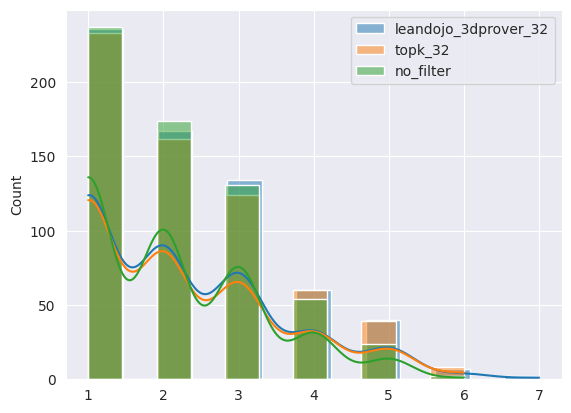

In [48]:

# plot all the proof lengths with a histogram and legend, with each key side by side in plot, using seaborn

import seaborn as sns

import matplotlib.pyplot as plt

for key, lens in proof_lens.items():
    sns.histplot(lens, label=key, kde=True)
plt.legend()
plt.show()




In [50]:
# for each length from 1 to max length, get the number of proofs of that length for each key

table = {i: [(k, len([a for a in lens if a == i])) for k, lens in proof_lens.items()] for i in range(1, 8)}
table





{1: [('leandojo_3dprover_32', 236), ('topk_32', 233), ('no_filter', 237)],
 2: [('leandojo_3dprover_32', 167), ('topk_32', 162), ('no_filter', 174)],
 3: [('leandojo_3dprover_32', 134), ('topk_32', 124), ('no_filter', 131)],
 4: [('leandojo_3dprover_32', 60), ('topk_32', 60), ('no_filter', 54)],
 5: [('leandojo_3dprover_32', 40), ('topk_32', 39), ('no_filter', 24)],
 6: [('leandojo_3dprover_32', 7), ('topk_32', 8), ('no_filter', 2)],
 7: [('leandojo_3dprover_32', 2), ('topk_32', 0), ('no_filter', 0)]}

In [74]:
# for each length from 1 to max length, get the number of proofs of that length for each key

table = {i: [(k, len([a for a in lens if a == i])) for k, lens in proof_lens.items()] for i in range(1, 7)}
table






{1: [('bestfs', 42),
  ('bestfs_8_top', 40),
  ('bestfs_16_top', 41),
  ('bestfs_32_top', 42),
  ('k16', 42),
  ('k8', 41),
  ('k32', 42)],
 2: [('bestfs', 14),
  ('bestfs_8_top', 8),
  ('bestfs_16_top', 11),
  ('bestfs_32_top', 13),
  ('k16', 13),
  ('k8', 10),
  ('k32', 13)],
 3: [('bestfs', 11),
  ('bestfs_8_top', 4),
  ('bestfs_16_top', 8),
  ('bestfs_32_top', 9),
  ('k16', 9),
  ('k8', 7),
  ('k32', 10)],
 4: [('bestfs', 0),
  ('bestfs_8_top', 0),
  ('bestfs_16_top', 2),
  ('bestfs_32_top', 3),
  ('k16', 3),
  ('k8', 1),
  ('k32', 4)],
 5: [('bestfs', 1),
  ('bestfs_8_top', 0),
  ('bestfs_16_top', 1),
  ('bestfs_32_top', 0),
  ('k16', 1),
  ('k8', 1),
  ('k32', 0)],
 6: [('bestfs', 0),
  ('bestfs_8_top', 1),
  ('bestfs_16_top', 2),
  ('bestfs_32_top', 1),
  ('k16', 2),
  ('k8', 1),
  ('k32', 1)]}

In [71]:
[k for k,v in min_lens.items() if v == 8]

['induction_divisibility_9div10tonm1']

In [ ]:
# def pass_at_k(n, c, k):
#     """
#     :param n: total number of samples
#     :param c: number of correct samples
#     :param k: k in pass@$k$
#     """
#     if n - c < k:
#         return 1.0
#     return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [116]:
# get the union (pass@k) over sets

union = traces_proved['bestfs_8_1'].union(
    traces_proved['bestfs_8_2'],
    traces_proved['bestfs_8_3'],
    traces_proved['bestfs_8_4'],
)

# 44, 56, 61, 63
len(union)

63

In [147]:
a = [44, 56, 61, 63] 
[i / 245 for i in a]

[0.17959183673469387,
 0.22857142857142856,
 0.24897959183673468,
 0.2571428571428571]

In [120]:
union = traces_proved['bestfs_16_1'].union(
    traces_proved['bestfs_16_2'],
    traces_proved['bestfs_16_3'],
    traces_proved['bestfs_16_4'],
)
len(union)

# 52, 70, 72, 74


74

In [148]:
a = [52, 70, 72, 74]
[i / 245 for i in a]

[0.21224489795918366,
 0.2857142857142857,
 0.2938775510204082,
 0.3020408163265306]

In [127]:
union = traces_proved['bestfs_32_1'].union(
    traces_proved['bestfs_32_2'],
    traces_proved['bestfs_32_3'],
    # traces_proved['bestfs_32_4'],
)
len(union)

# 69, 71, 73, 73


73

In [149]:
a = [69, 71, 73, 73]
[i / 245 for i in a]

[0.2816326530612245,
 0.2897959183673469,
 0.2979591836734694,
 0.2979591836734694]

In [131]:
union = traces_proved['dpp_8_1'].union(
    traces_proved['dpp_8_2'],
    traces_proved['dpp_8_3'],
    traces_proved['dpp_8_4'],

)
len(union)

# 61, 64, 65, 70


70

In [150]:
a = [61, 64, 65, 70]
[i / 245 for i in a]

[0.24897959183673468,
 0.2612244897959184,
 0.2653061224489796,
 0.2857142857142857]

In [139]:
union = traces_proved['dpp_16_1'].union(
    traces_proved['dpp_16_2'],
    traces_proved['dpp_16_3'],
    traces_proved['dpp_16_4'],
)
len(union)

# 68, 72, 73, 76


76

In [151]:
a = [68, 72, 73, 76]
[i / 245 for i in a]


[0.27755102040816326,
 0.2938775510204082,
 0.2979591836734694,
 0.31020408163265306]

In [145]:
union = traces_proved['dpp_32_1'].union(
    traces_proved['dpp_32_2'],
    traces_proved['dpp_32_3'],
    traces_proved['dpp_32_4'],
)

len(union)

# 70, 71, 73, 73


73

In [152]:
a = [70, 71, 73, 73]
[i / 245 for i in a]

[0.2857142857142857,
 0.2897959183673469,
 0.2979591836734694,
 0.2979591836734694]

In [88]:
trace_proofs.values()




dict_values([[('mathd_numbertheory_127', ['norm_num', 'symmetry', 'norm_num [<a>finset.sum_range_succ</a>]']), ('mathd_algebra_354', ['linarith']), ('mathd_algebra_441', ['field_simp', 'ring']), ('mathd_algebra_80', ['contrapose! h₁', 'contrapose! h₀', 'exfalso', 'rw [<a>div_eq_iff</a>] at h₀', 'apply h₁', 'linarith', 'intro hx', 'simpa [hx] using h₀']), ('mathd_algebra_139', ['norm_num [h₀, h₀]']), ('mathd_algebra_107', ['rw [<a>sq</a>, <a>sq</a>, <a>sq</a>]', 'abel', 'linear_combination h₀']), ('mathd_algebra_427', ['rwa <a>add_comm</a> at h₀ h₁', 'linarith']), ('mathd_algebra_329', ['linarith']), ('mathd_algebra_302', ['simp [<a>complex.I_sq</a>]', 'norm_num']), ('mathd_numbertheory_247', ['revert h₀', 'rw <a>nat.mul_mod</a>', 'cases <a>nat.mod_two_eq_zero_or_one</a> n', 'simp [h, <a>nat.mul_mod</a>]', 'simp [h, <a>nat.odd_of_mod_four_eq_three</a>]']), ('mathd_algebra_270', ['classical', 'norm_num [h₀]']), ('mathd_numbertheory_345', ['norm_num']), ('mathd_algebra_419', ['rw [h₀]', '

In [114]:
baseline_union = traces_proved['bestfs_8_1'].union(
    traces_proved['bestfs_8_2'],
    traces_proved['bestfs_8_3'],
    traces_proved['bestfs_8_4'],
    
    traces_proved['bestfs_16_1'],
    traces_proved['bestfs_16_2'],
    traces_proved['bestfs_16_3'],
    traces_proved['bestfs_16_4'],
    
    traces_proved['bestfs_32_1'],
    traces_proved['bestfs_32_2'],
    traces_proved['bestfs_32_3'],
    
    traces_proved['bestfs_8_top'],
    traces_proved['bestfs_16_top'],
    traces_proved['bestfs_32_top'],
    
)


In [115]:
len(baseline_union)

77

In [116]:
dpp_union = traces_proved['dpp_8_1'].union(
    
    traces_proved['dpp_8_2'],
    traces_proved['dpp_8_3'],
    traces_proved['dpp_8_4'],
    
    traces_proved['dpp_16_1'],
    traces_proved['dpp_16_2'],
    traces_proved['dpp_16_3'],
    traces_proved['dpp_16_4'],
    
    traces_proved['dpp_32_1'],
    traces_proved['dpp_32_2'],
    traces_proved['dpp_32_3'],
    traces_proved['dpp_32_4'],
    
)

AttributeError: 'list' object has no attribute 'union'

In [117]:
len(dpp_union)

77

In [118]:
baseline_union.difference(dpp_union)


{'mathd_algebra_296'}

In [119]:

dpp_union.difference(baseline_union)


{'induction_12dvd4expnp1p20'}

In [121]:
shortest_proofs = {}

for key, proofs in trace_proofs.items():
    for proof in proofs:
        if proof[0] not in shortest_proofs:
            shortest_proofs[proof[0]] = proof[1]
        elif len(proof[1]) < len(shortest_proofs[proof[0]]):
            shortest_proofs[proof[0]] = proof[1]

In [122]:
len(shortest_proofs)

78

In [123]:
lens = [len(s) for s in shortest_proofs.values()]

# show table of values of lens, from 1 to 5

table = {i: len([a for a in lens if a == i]) for i in range(1, 6)}
table


{1: 47, 2: 19, 3: 6, 4: 3, 5: 3}

In [87]:
len([a for a in lens if a == 5])

4

In [133]:
long_proofs = [k  for k, a in shortest_proofs.items() if len(a) >= 4]

In [135]:
len(long_proofs)

6

In [134]:
baseline_count = 0
dpp_count = 0

for l in long_proofs:
    if l in baseline_union:
        baseline_count +=1 
    if l in dpp_union:
        dpp_count += 1
        
print (baseline_count, dpp_count)

5 6


In [131]:
for key, proofs in trace_proofs.items():
    for proof in proofs:
        if 'mathd_algebra_296' == proof[0] or 'imo_1968_p5_1' == proof[0] or 'induction_12dvd4expnp1p20' == proof[0]:
            print(key, proof)
    
    

bestfs_32_1 ('mathd_algebra_296', ['rw [<a>abs_sub_comm</a>, <a>abs_of_nonneg</a>]', 'norm_num [<a>sq</a>]', 'linarith'])
dpp_8_4 ('induction_12dvd4expnp1p20', ['cases n', 'norm_num', "simp [<a>pow_succ'</a>]", 'transitivity', 'apply <a>nat.dvd_of_mod_eq_zero</a>', 'rw <a>nat.mod_def</a>', 'norm_num', 'norm_num'])
dpp_8_4 ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"])
dpp_16_1 ('induction_12dvd4expnp1p20', ['transitivity', 'apply <a>nat.dvd_of_mod_eq_zero</a>', 'rw <a>nat.mod_def</a>', 'norm_num', 'norm_num'])
dpp_16_2 ('imo_1968_p5_1', ["have h₀' : 0 < 1/2", 'contrapose! h₀', 'linarith', 'use 1', "norm_num at h₀'"])
dpp_16_3 ('imo_1968_p5_1', ['use 0', 'simp', "have h₀' : 0 < 1/2", 'contrapose! h₀', 'linarith', "norm_num at h₀'"])
dpp_32_3 ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"])
bestfs_8_top ('imo_1968_p5_1', ['use 0', 'simp [h₁]', "have h₀' : 0 < 1/2", 'norm_num', "norm_num at h₀'"]

In [ ]:
union = traces_proved['k16'].union(
    # traces_proved['k16'],
    # traces_proved['k8'],
    # traces_proved['k32_e0.5'],
    traces_proved['k16_e0.5'],
    # traces_proved['k8_e0.5'],
    # traces_proved['k32_t1'],
    traces_proved['k16_t1'],
    # traces_proved['k8_t1'],
    # traces_proved['k32_theta4'],
    traces_proved['k16_theta4'],
    # traces_proved['k8_theta4'],
    # traces_proved['k32_e0.1'],
    traces_proved['k16_e0.1'],
    # traces_proved['k8_e0.1'],
)

len(union)


In [ ]:

union = traces_proved['bestfs_8_top'].union(
    traces_proved['bestfs_8_random'],
    traces_proved['bestfs_16_top'],
    traces_proved['bestfs_16_random'],
    traces_proved['bestfs_32_top'],
    traces_proved['bestfs_32_random'],
)
len(union)